In [ ]:
#Import basic libraries--
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Load Dataset
df=pd.read_csv('/content/drive/MyDrive/zomato.csv')
df

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51712,https://www.zomato.com/bangalore/best-brews-fo...,"Four Points by Sheraton Bengaluru, 43/3, White...",Best Brews - Four Points by Sheraton Bengaluru...,No,No,3.6 /5,27,080 40301477,Whitefield,Bar,NaN,Continental,"1,500","[('Rated 5.0', ""RATED\n Food and service are ...",[],Pubs and bars,Whitefield
51713,https://www.zomato.com/bangalore/vinod-bar-and...,"Number 10, Garudachar Palya, Mahadevapura, Whi...",Vinod Bar And Restaurant,No,No,NaN,0,+91 8197675843,Whitefield,Bar,NaN,Finger Food,600,[],[],Pubs and bars,Whitefield
51714,https://www.zomato.com/bangalore/plunge-sherat...,Sheraton Grand Bengaluru Whitefield Hotel & Co...,Plunge - Sheraton Grand Bengaluru Whitefield H...,No,No,NaN,0,NaN,Whitefield,Bar,NaN,Finger Food,"2,000",[],[],Pubs and bars,Whitefield
51715,https://www.zomato.com/bangalore/chime-sherato...,Sheraton Grand Bengaluru Whitefield Hotel & Co...,Chime - Sheraton Grand Bengaluru Whitefield Ho...,No,Yes,4.3 /5,236,080 49652769,"ITPL Main Road, Whitefield",Bar,"Cocktails, Pizza, Buttermilk",Finger Food,"2,500","[('Rated 4.0', 'RATED\n Nice and friendly pla...",[],Pubs and bars,Whitefield


In [ ]:
df.isnull().sum()

,0
url,0
address,0
name,0
online_order,0
book_table,0
rate,7775
votes,0
phone,1208
location,21
rest_type,227


In [ ]:
#Remove null values
df.dropna(inplace=True)

In [ ]:
#Check duplicates
df.duplicated().sum()

np.int64(0)

In [ ]:
#clean Rate column (remove'/5')
df['rate']=df['rate'].apply(lambda x:str(x).split('/')[0]).replace('New',None)
df['rate']=pd.to_numeric(df['rate'],errors='coerce')

In [ ]:
# Clean 'approx_cost(for two people)' column (remove commas)
df['approx_cost(for two people)']=df['approx_cost(for two people)'].str.replace(',','')
df['approx_cost(for two people)']=pd.to_numeric(df['approx_cost(for two people)'],errors='coerce')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23193 entries, 0 to 51715
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   url                          23193 non-null  object 
 1   address                      23193 non-null  object 
 2   name                         23193 non-null  object 
 3   online_order                 23193 non-null  object 
 4   book_table                   23193 non-null  object 
 5   rate                         23046 non-null  float64
 6   votes                        23193 non-null  int64  
 7   phone                        23193 non-null  object 
 8   location                     23193 non-null  object 
 9   rest_type                    23193 non-null  object 
 10  dish_liked                   23193 non-null  object 
 11  cuisines                     23193 non-null  object 
 12  approx_cost(for two people)  23193 non-null  int64  
 13  reviews_list         

In [ ]:
#Top 10 cuisines
Top_cusines=df['cuisines'].value_counts().head(10)

/tmp/ipython-input-469061058.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


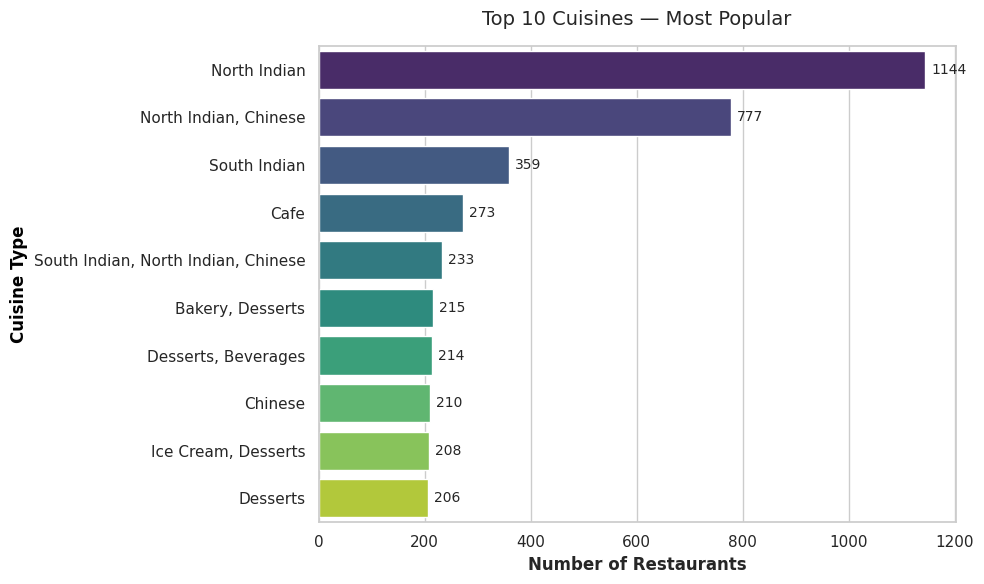

In [ ]:
# Top 10 cuisines
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Horizontal barplot with a sleek colormap
ax = sns.barplot(
    x=Top_cusines.values,
    y=Top_cusines.index,
    palette="viridis"
)

# Annotate bars with their numeric values
for bar in ax.patches:
    width = bar.get_width()
    ax.text(
        width + max(Top_cusines.values)*0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{int(width)}',
        va='center',
        fontsize=10
    )

# Titles and labels
ax.set_title("Top 10 Cuisines — Most Popular", fontsize=14, pad=15)
ax.set_xlabel("Number of Restaurants", fontsize=12,fontweight='bold')
ax.set_ylabel('Cuisine Type', fontsize=12, fontweight='bold', color='black')


plt.tight_layout()
plt.show()


In [ ]:
# Top 10 Average rating per location
Top_avg_rate=df.groupby('location')['rate'].mean().sort_values(ascending=False).head(10)

/tmp/ipython-input-3629161718.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


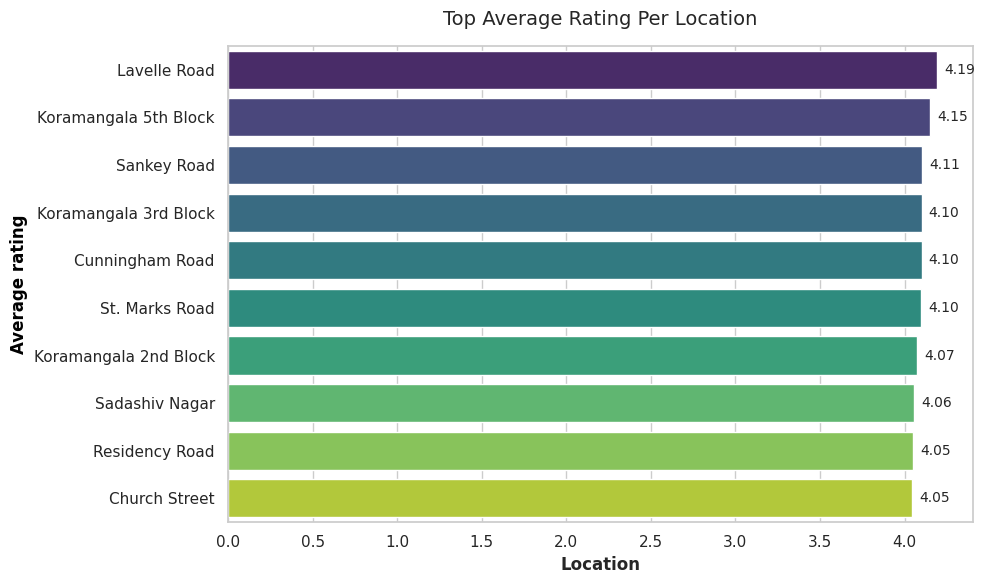

In [ ]:
#Plot --Top 10 Average Rating per location

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Horizontal barplot with a sleek colormap
ax = sns.barplot(
    x=Top_avg_rate.values,
    y=Top_avg_rate.index,
    palette="viridis"
)

# Annotate bars with their numeric values
for bar in ax.patches:
    width = bar.get_width()
    ax.text(
        width + max(Top_avg_rate.values)*0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{width:.2f}',
        va='center',
        fontsize=10
    )

# Titles and labels
ax.set_title("Top Average Rating Per Location", fontsize=14, pad=15)
ax.set_xlabel("Location", fontsize=12,fontweight='bold')
ax.set_ylabel('Average rating', fontsize=12, fontweight='bold', color='black')


plt.tight_layout()
plt.show()

In [ ]:
#Cost for Two Distribution Plot
import plotly.express as px

fig = px.histogram(
    df,
    x='approx_cost(for two people)',
    nbins=30,
    title='Cost for Two Distribution',
    labels={'approx_cost(for two people)': 'Cost for Two'},
    template='plotly_white'
)
fig.show()


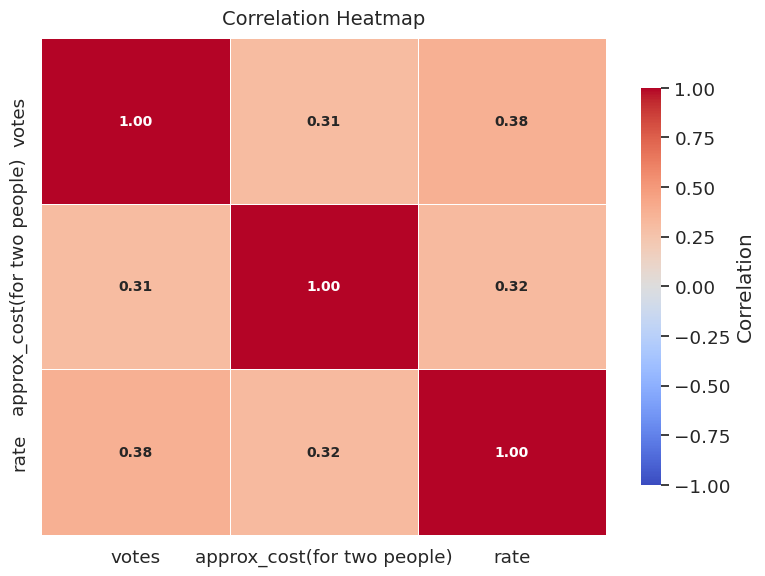

In [106]:
#Correlation between numeric features
sns.set_style("white")
sns.set_context("notebook", font_scale=1.2)

plt.figure(figsize=(8, 6))
sns.heatmap(
    df[['votes', 'approx_cost(for two people)', 'rate']].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1, center=0,
    linewidths=0.5, linecolor='white',
    annot_kws={"size":10, "weight":"bold"},
    cbar_kws={"shrink":0.8, "label":"Correlation"}
)

plt.title("Correlation Heatmap", fontsize=14, pad=10)
plt.tight_layout()
plt.show()
